In [1]:
import numpy as np
import matplotlib.pyplot as plt
print("Numpy version:", np.__version__)
print("环境配置成功")

Numpy version: 1.23.5
环境配置成功


In [3]:
# 准备数据：广告投入
X=np.array([1,2,3,4,5])
# 真实结果：销售额
y=np.array([3,5,7,9,11])
print("X=",X)
print("y=",y)


X= [1 2 3 4 5]
y= [ 3  5  7  9 11]


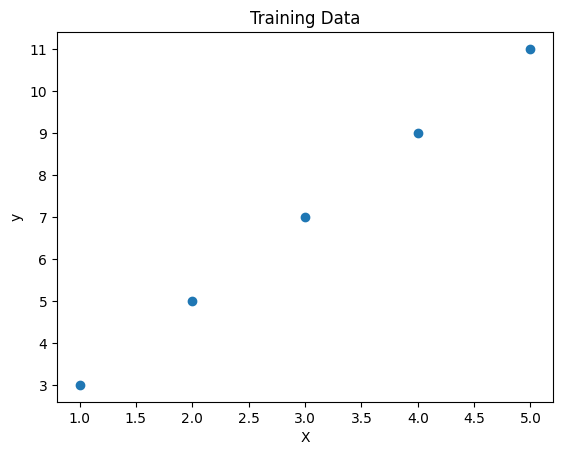

In [4]:
plt.scatter(X,y)
plt.xlabel("X")
plt.ylabel("y")
plt.title("Training Data")
plt.show()

In [5]:
w=1
b=0
y_pred=w*X+b
print("预测结果：",y_pred)

预测结果： [1 2 3 4 5]


In [6]:
errors=y_pred-y
mse=np.mean(errors**2)
print("预测误差",errors)
print("均方误差",mse)

预测误差 [-2 -3 -4 -5 -6]
均方误差 18.0


In [8]:
errors=np.array([2,-3,1])
print(np.sum(errors))
print(np.sum(np.abs(errors)))
print(np.sum(errors**2))
print(np.mean(errors**2))


0
6
14
4.666666666666667


In [9]:
import numpy as np

X = np.array([1, 2, 3, 4, 5])
y = np.array([3, 5, 7, 9, 11])

def mse(w, b):
    y_pred = w * X + b
    return np.mean((y_pred - y) ** 2)

print("w=1, b=0:", mse(1, 0))
print("w=2, b=0:", mse(2, 0))
print("w=2, b=1:", mse(2, 1))
print("w=3, b=1:", mse(3, 1))

w=1, b=0: 18.0
w=2, b=0: 1.0
w=2, b=1: 0.0
w=3, b=1: 11.0


训练完成！
w = 2.003880582342283
b = 0.9859898664422495
最终损失 = 3.5969908013330074e-05


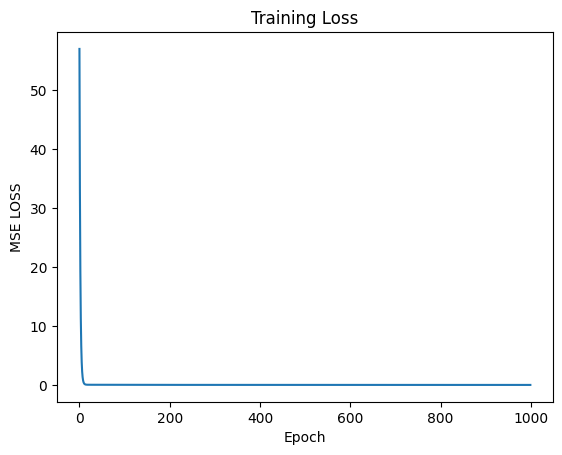

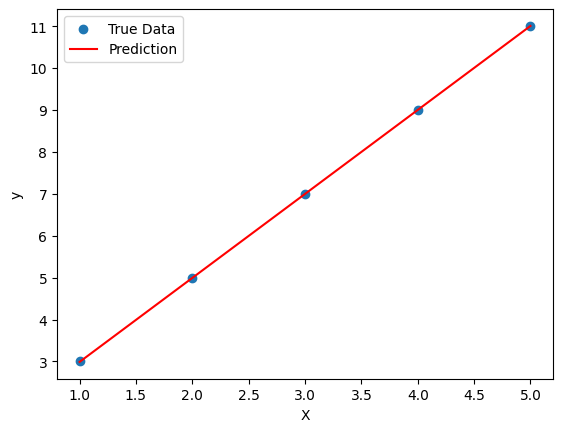

In [10]:
import numpy as np
import matplotlib.pyplot as plt
X=np.array([1,2,3,4,5])
y=np.array([3,5,7,9,11])
w=0.0
b=0.0
# 超参数
lr=0.01
epochs=1000
# 如下要记录损失函数的数值是多少
loss_history=[]
for epoch in range(epochs):
    # 前向传播
    y_pred=w*X+b
    # 计算损失函数
    loss=np.mean((y_pred-y)**2)
    loss_history.append(loss)
    # 反向传播计算梯度 
    dw=(2/len(X))*np.sum((y_pred-y)*X)
    db=(2/len(X))*np.sum(y_pred-y)
    # 更新参数
    w=w-lr*dw
    b=b-lr*db
print("训练完成！")
print("w =", w)
print("b =", b)
print("最终损失 =", loss_history[-1])
# 绘制损失曲线
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("MSE LOSS")
plt.title("Training Loss")
plt.show()
# 绘制拟合效果
plt.scatter(X,y,label="True Data")
plt.plot(X,w*X+b,color="red",label="Prediction")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()


[ 2.23219061  0.08233609 -0.74884691]
0.0034565265409558918
最终损失 12.905353781995302


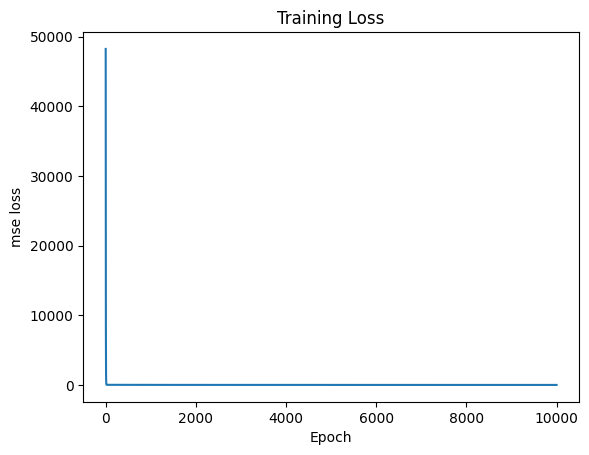

In [11]:
# 开始进阶，从一个特征变成多个
import numpy as np
import matplotlib.pyplot as plt
X=np.array([
    [50,1,10],
    [60,2,8],
    [80,2,5],
    [100,3,4],
    [120,3,2],
    [150,4,1]
],dtype=float)
# 模拟房价
y=np.array([100,130,180,220,270,330],dtype=float)
# 初始化参数
w=np.zeros(X.shape[1])
b=0.0
# 超参数
lr=0.00001
epochs=10000

loss_history=[]
for epochs in range(epochs):
    # 前向传播
    y_pred=X@w+b
    # 计算损失函数
    loss=np.mean((y_pred-y)**2)
    loss_history.append(loss)
    # 梯度
    dw = (2 / len(X)) * (X.T @ (y_pred - y))
    db = (2 / len(X)) * np.sum(y_pred - y)
    # 更新参数
    w=w-lr*dw
    b=b-lr*db

print(w)
print(b)
print("最终损失",loss_history[-1])

plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("mse loss")
plt.title("Training Loss")
plt.show()

In [29]:
# 封装这个模型
import numpy as np
class LinearRegression:
    def __init__(self,n_features):
        self.w=np.zeros(n_features)
        self.b=0.0
    # 前向传播
    def predict(self,X):
        return X@self.w+self.b
    # 计算损失
    def loss(self,y_pred,y):
        return np.mean((y_pred-y)**2)
    # 定义训练模型
    def fit(self,X,y,lr=0.00001,epochs=10000):
        self.loss_history=[]
        n=len(X)
        for epoch in range(epochs):
            y_pred=self.predict(X)
            current_loss=self.loss(y_pred,y)
            self.loss_history.append(current_loss)

            errors=y_pred-y
            dw=(2/n)*(X.T@errors)
            db=(2/n)*np.sum(errors)
            self.w-=lr*dw
            self.b-=lr*db
           


In [30]:
X = np.array([
    [50, 1, 10],
    [60, 2, 8],
    [80, 2, 5],
    [100, 3, 4],
    [120, 3, 2],
    [150, 4, 1]
], dtype=float)

y = np.array([100, 130, 180, 220, 270, 330], dtype=float)

model=LinearRegression(n_features=X.shape[1])
model.fit(X,y,lr=0.00001,epochs=10000)
predictions=model.predict(X)
print("预测结果：",predictions)




预测结果： [104.20685425 128.10879031 174.99914334 220.47413863 266.61564475
 334.41254619]


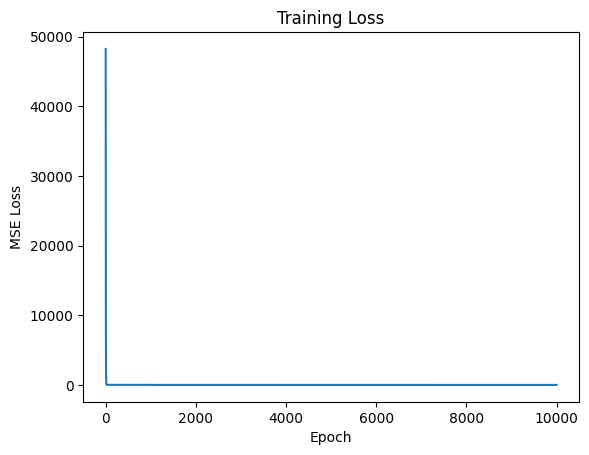

In [31]:
import matplotlib.pyplot as plt

plt.plot(model.loss_history)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training Loss")
plt.show()

In [ ]:
## 从numpy进入pytorch
import torch
X=torch.tensor([
    [50, 1, 10],
    [60, 2, 8],
    [80, 2, 5],
    [100, 3, 4],
    [120, 3, 2],
    [150, 4, 1]
], dtype=torch.float32)

y = torch.tensor(
    [100, 130, 180, 220, 270, 330],
    dtype=torch.float32
)
# 在设置初始化参数之前，我们需要让这个pytorch进行梯度可追踪
w=torch.zeros(3,requires_grad=True)
b=torch.tensor(0.0,requires_grad=True)

optimizer = torch.optim.SGD([w, b], lr=0.00001)
for epoch in range(10000):

    # 前向传播
    y_pred = X @ w + b

    # Loss
    loss = torch.mean((y_pred - y) ** 2)

    # 计算梯度
    loss.backward()

    # 更新参数
    optimizer.step()

    # 清空旧梯度,pytorch在每次反向传播时会累积梯度，所以我们需要在每次更新参数后清空旧梯度
    optimizer.zero_grad()

print("w =", w)
print("b =", b)
print("loss =", loss)




In [33]:
# 来喽！！下一步，Pytorch的Module
import torch
import torch.nn as nn

X = torch.tensor([
    [50, 1, 10],
    [60, 2, 8],
    [80, 2, 5],
    [100, 3, 4],
    [120, 3, 2],
    [150, 4, 1]
], dtype=torch.float32)

y = torch.tensor(
    [100, 130, 180, 220, 270, 330],
    dtype=torch.float32
)


class LinearRegression(nn.Module):
    def __init__(self,n_features):
        super().__init__()
        self.linear = nn.Linear(n_features, 1)
    def forward(self,X):
        return self.linear(X)

model = LinearRegression(3)

loss_fn = nn.MSELoss()

optimizer = torch.optim.SGD(
    model.parameters(),
    lr=0.00001
)

for epoch in range(10000):

    # ① 前向传播
    y_pred = model(X)

    # ② 计算损失
    loss = loss_fn(y_pred.squeeze(), y)

    # ③ 反向传播
    loss.backward()

    # ④ 更新参数
    optimizer.step()


    # ⑤ 清空梯度
    optimizer.zero_grad()

print(model.linear.weight)
print(model.linear.bias)
print(loss)

Parameter containing:
tensor([[ 2.2379,  0.0117, -0.7039]], requires_grad=True)
Parameter containing:
tensor([-0.5764], requires_grad=True)
tensor(13.1736, grad_fn=<MseLossBackward0>)


NameError: name 'linear' is not defined